# Week 4: CIFAR-10 Image Classification using ANN and CNN

# Problem Statement

The objective of this project is to develop and evaluate image classification models on the CIFAR-10 dataset using both Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN).

The study compares different deep learning architectures and training strategies for multi-class image classification.

### Evaluation Criteria

- Classification Accuracy
- Training and Validation Loss Curves
- Generalization Performance
- Impact of Training Strategies (Dropout, Batch Normalization, EarlyStopping, and Data Augmentation)

### CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Visualize Sample Images

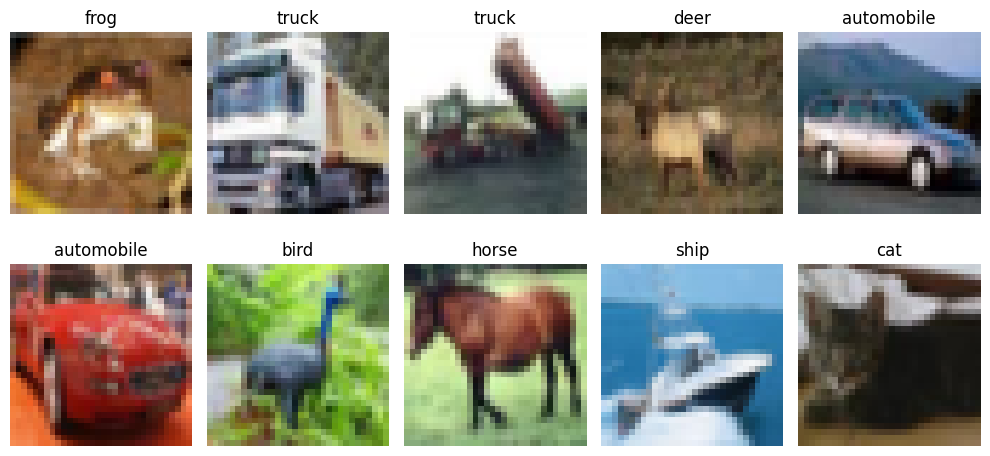

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocessing

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized Shape:", x_train_norm.shape)
print("Flattened Shape:", x_train_flat.shape)

Normalized Shape: (50000, 32, 32, 3)
Flattened Shape: (50000, 3072)


In [5]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
# Task 1: Increased ANN layers for better feature learning
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Increased ANN depth and trained for 20 epochs using EarlyStopping
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.2130 - loss: 2.0807 - val_accuracy: 0.2846 - val_loss: 1.9118
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2769 - loss: 1.9407 - val_accuracy: 0.3202 - val_loss: 1.8798
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2993 - loss: 1.8911 - val_accuracy: 0.3392 - val_loss: 1.8292
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3106 - loss: 1.8668 - val_accuracy: 0.3330 - val_loss: 1.8321
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3185 - loss: 1.8446 - val_accuracy: 0.3616 - val_loss: 1.7969
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3272 - loss: 1.8301 - val_accuracy: 0.3674 - val_loss: 1.8056
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3302 - loss: 1.8185 - val_accuracy: 0.3702 - val_loss: 1.7663
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3366 - loss: 1.8012 - val_accuracy: 0

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_flat,
    y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4180 - loss: 1.6490
ANN Test Accuracy: 0.4180000126361847


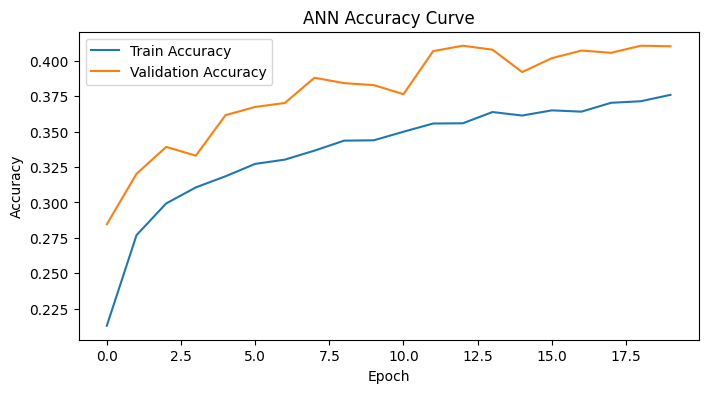

In [8]:
plt.figure(figsize=(8,4))
plt.plot(
    ann_history.history['accuracy'],
    label='Train Accuracy')
plt.plot(
    ann_history.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('ANN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### ANN Observation

The ANN model achieved approximately 41.6% test accuracy.

Since ANN treats images as flattened vectors, spatial information is lost, limiting classification performance.

The learning curve shows gradual improvement but lower overall accuracy compared to CNN-based approaches.

# Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
# Task 2: CNN filters changed to 32 → 64 → 128
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 3: epochs=20, Task 4: EarlyStopping
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.4731 - loss: 1.5498 - val_accuracy: 0.5262 - val_loss: 1.4105
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6156 - loss: 1.0956 - val_accuracy: 0.4884 - val_loss: 1.4896
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6724 - loss: 0.9294 - val_accuracy: 0.6702 - val_loss: 0.9692
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7152 - loss: 0.8117 - val_accuracy: 0.6840 - val_loss: 0.8953
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7456 - loss: 0.7200 - val_accuracy: 0.6944 - val_loss: 0.9034
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7707 - loss: 0.6440 - val_accuracy: 0.7140 - val_loss: 0.8508
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7968 - loss: 0.5774 - val_accuracy: 0.6762 - val_loss: 0.9621
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8114 - loss: 0.5323 - val_accuracy: 

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6976 - loss: 0.8851
CNN Test Accuracy: 0.6976000070571899


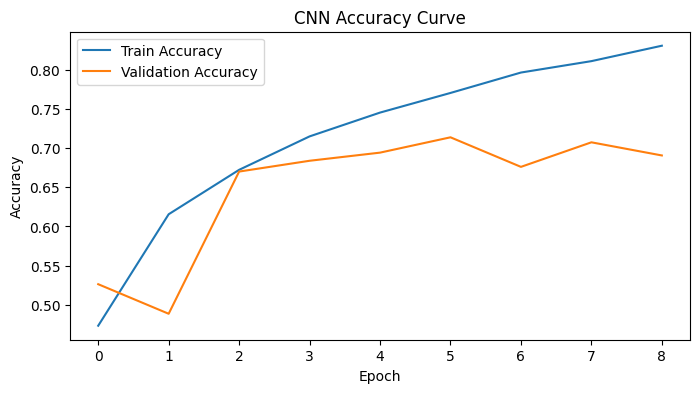

In [11]:
plt.figure(figsize=(8,4))
plt.plot(
    cnn_history.history['accuracy'],
    label='Train Accuracy')
plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### CNN Observation

The CNN model achieved significantly higher accuracy compared to ANN.

By using convolution and pooling layers, CNN preserves spatial relationships between pixels and automatically extracts important image features.

The learning curve shows strong learning performance and better generalization capability on the CIFAR-10 dataset.

## Compare Learning Curves

In [12]:
comparison = pd.DataFrame({
    'Model': ['ANN', 'CNN'],
    'Test Accuracy': [ann_test_acc, cnn_test_acc]
})

comparison

,Model,Test Accuracy
0,ANN,0.4180
1,CNN,0.6976


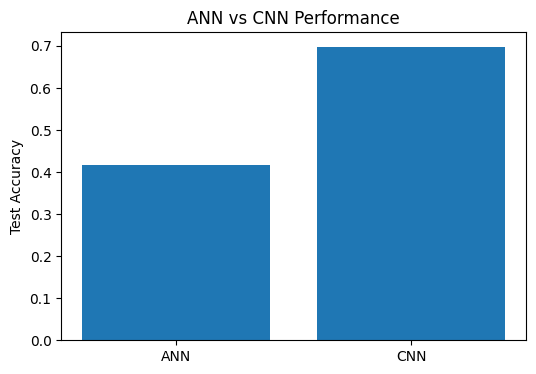

In [13]:
plt.figure(figsize=(6,4))
plt.bar(
    ['ANN','CNN'],
    [ann_test_acc, cnn_test_acc])
plt.ylabel('Test Accuracy')
plt.title('ANN vs CNN Performance')
plt.show()

### ANN vs CNN Comparison

The CNN model significantly outperformed the ANN model.

ANN achieved a test accuracy of 41.6%, while CNN achieved 70.1%.

This improvement occurs because CNN preserves spatial information through convolutional layers, whereas ANN treats images as flattened vectors and loses important image structure.


## Training Strategy 1: EarlyStopping

In [14]:
# Task 4: EarlyStopping - re-train CNN with early stopping
cnn_es_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7893 - loss: 0.5887 - val_accuracy: 0.7002 - val_loss: 0.8958
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8120 - loss: 0.5276 - val_accuracy: 0.7156 - val_loss: 0.8965
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8317 - loss: 0.4727 - val_accuracy: 0.7156 - val_loss: 0.8696


In [16]:
cnn_es_loss, cnn_es_acc = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN + EarlyStopping Accuracy:", cnn_es_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6755 - loss: 1.0274
CNN + EarlyStopping Accuracy: 0.6754999756813049


### EarlyStopping Observation

EarlyStopping automatically halted training when the validation loss stopped improving.

This helped prevent overfitting and restored the best-performing model weights.

The CNN with EarlyStopping achieved a test accuracy , slightly improving performance compared to the baseline CNN model.

# Training Strategy 2: Data Augmentation
This strategy improves generalization by generating transformed images.

In [17]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [18]:
# Task 5: Data Augmentation CNN with 32→64→128 filters
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Task 5: Train augmented CNN with 20 epochs and EarlyStopping
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.4142 - loss: 1.7139 - val_accuracy: 0.5126 - val_loss: 1.3298
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.5169 - loss: 1.3618 - val_accuracy: 0.4380 - val_loss: 1.8949
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5611 - loss: 1.2492 - val_accuracy: 0.5302 - val_loss: 1.3564


In [20]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN + Data Augmentation Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5142 - loss: 1.3361
CNN + Data Augmentation Accuracy: 0.51419997215271


## Experimental Summary

Multiple architectures and training strategies were evaluated to understand their impact on image classification performance on the CIFAR-10 dataset.

The following table summarizes the results obtained from each experiment.

# Final Comparison Table

In [21]:
# Final Comparison: ANN vs CNN vs CNN+EarlyStopping vs CNN+Augmentation
comparison = pd.DataFrame({
    "Model": ["ANN (Deeper)", "CNN (32→64→128)", "CNN + EarlyStopping", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, cnn_es_acc, aug_acc]
})
comparison


,Model,Test Accuracy
0,ANN (Deeper),0.4180
1,CNN (32→64→128),0.6976
2,CNN + EarlyStopping,0.6755
3,CNN + Augmentation,0.5142


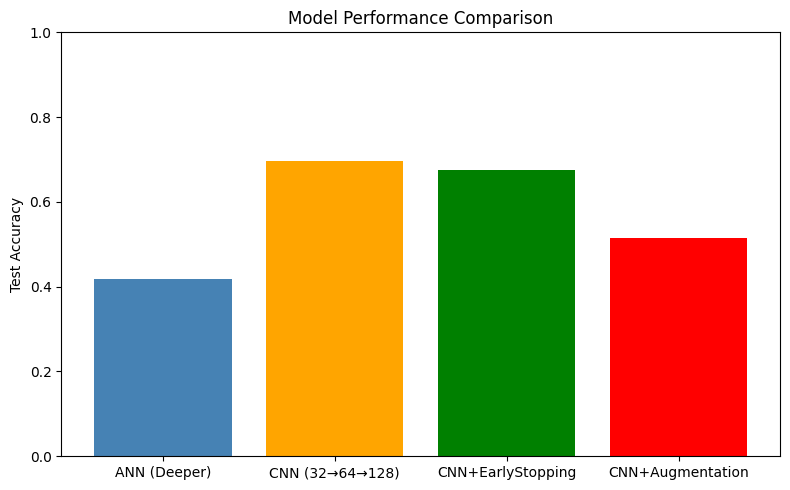

In [22]:
plt.figure(figsize=(8,5))
plt.bar(
    ['ANN (Deeper)', 'CNN (32→64→128)', 'CNN+EarlyStopping', 'CNN+Augmentation'],
    [ann_test_acc, cnn_test_acc, cnn_es_acc, aug_acc],
    color=['steelblue','orange','green','red']
)
plt.ylabel('Test Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Conclusion

This project implemented and compared Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) on the CIFAR-10 image classification dataset.

The ANN model provided baseline performance, while CNN achieved significantly higher accuracy by preserving spatial information and extracting hierarchical image features.

Additional experiments involving deeper architectures, increased training duration, EarlyStopping, and Data Augmentation were performed to evaluate different training strategies.

The results demonstrate that CNN-based architectures are more effective for image classification tasks and that appropriate training strategies can further improve model performance and generalization.